# Module 4, Class 3: Decision Trees and Random Forests

**Student:** Firdavs Boliev  
**Dataset:** Telco Customer Churn

This notebook compares one decision tree with a random forest using simple classification metrics.


## 0. Setup

In [1]:
# Import the libraries needed for preprocessing, tree models, metrics, and plots.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")


Setup complete.


## 1. Load and Preprocess Data

In [2]:
# Load and preprocess the Telco dataset so tree models can use numeric arrays.
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Standardize
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocess (we need the transformed data for tree visualization)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Get feature names
ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

print(f"Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"Total features after encoding: {len(all_feature_names)}")


Train: (5634, 23), Test: (1409, 23)
Total features after encoding: 23


## 2. Decision Tree Classifier

In [3]:
# Train a small decision tree and evaluate it on the test set.
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_proc, y_train)
y_pred_dt = dt.predict(X_test_proc)
y_proba_dt = dt.predict_proba(X_test_proc)[:, 1]

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))


Decision Tree Results:
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



### Visualize the Decision Tree

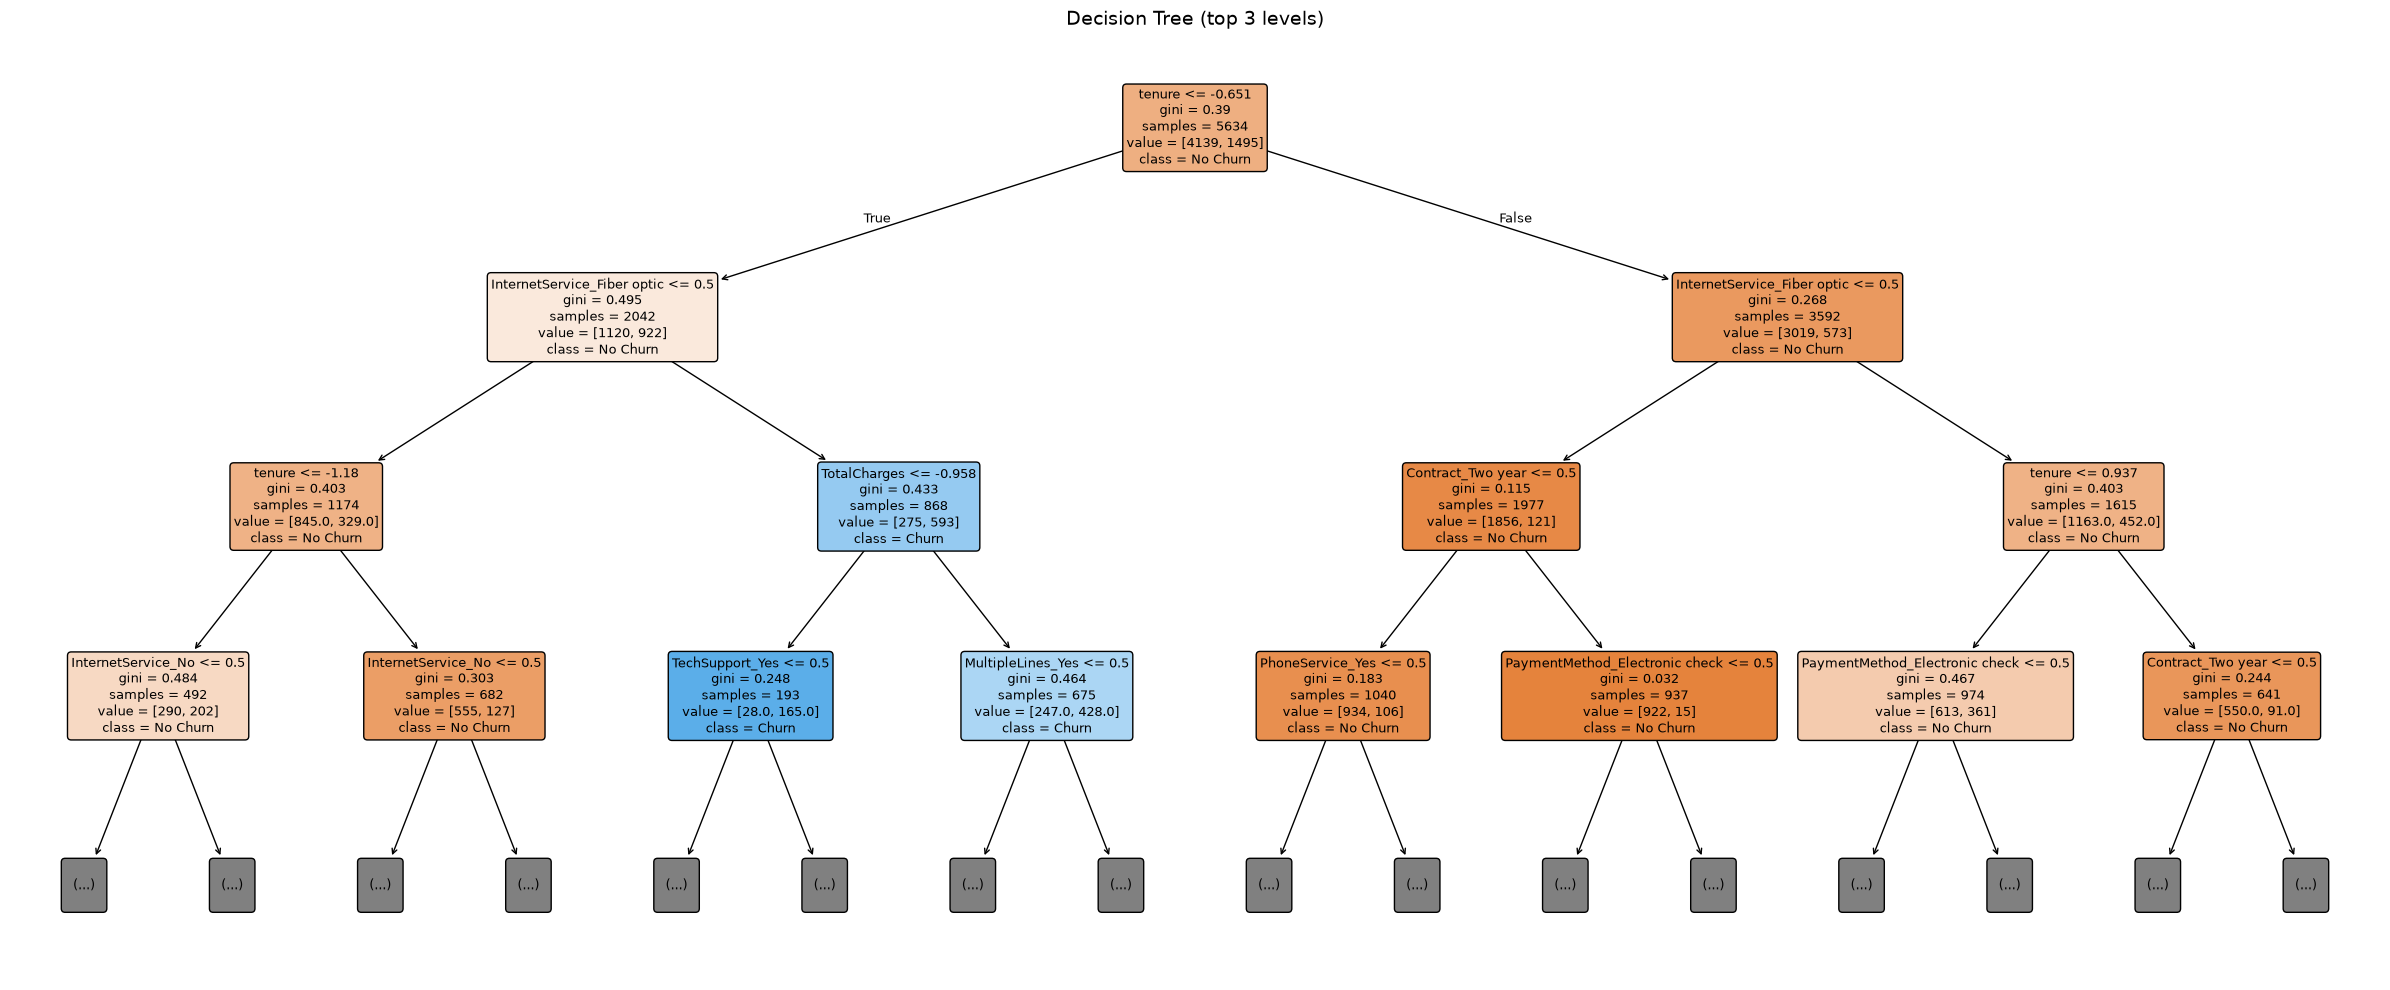

In [4]:
# Plot the top levels of the decision tree for an interpretable view.
plt.figure(figsize=(24, 10))
plot_tree(
    dt,
    max_depth=3,  # Show only top 3 levels for readability
    feature_names=all_feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree (top 3 levels)', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Random Forest Classifier

In [5]:
# Train a random forest and evaluate it on the same test set.
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_proc, y_train)
y_pred_rf = rf.predict(X_test_proc)
y_proba_rf = rf.predict_proba(X_test_proc)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


Random Forest Results:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Feature Importance

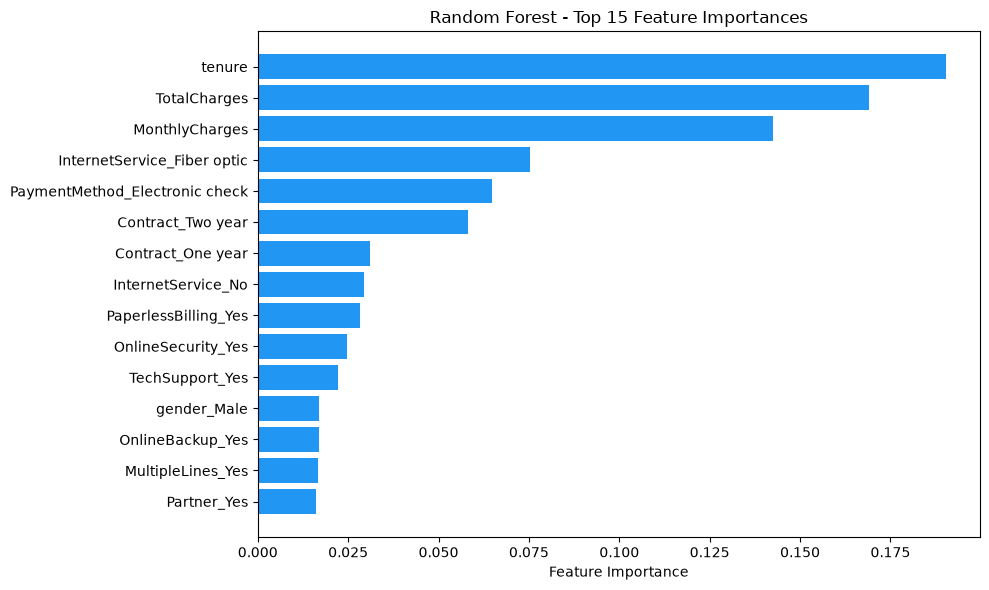

                       Feature  Importance
                        tenure    0.190255
                  TotalCharges    0.168938
                MonthlyCharges    0.142622
   InternetService_Fiber optic    0.075274
PaymentMethod_Electronic check    0.064648
             Contract_Two year    0.058213
             Contract_One year    0.030902
            InternetService_No    0.029381
          PaperlessBilling_Yes    0.028264
            OnlineSecurity_Yes    0.024784
               TechSupport_Yes    0.022211
                   gender_Male    0.016915
              OnlineBackup_Yes    0.016799
             MultipleLines_Yes    0.016567
                   Partner_Yes    0.016086


In [6]:
# Plot the most important random forest features.
importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 15
top_15 = feat_imp_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'][::-1], top_15['Importance'][::-1], color='#2196f3')
plt.xlabel('Feature Importance')
plt.title('Random Forest - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print(top_15.to_string(index=False))


## 4. Comparison Table

In [7]:
# Compare the decision tree and random forest in one table.
def get_metrics(y_true, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

comparison = pd.DataFrame([
    get_metrics(y_test, y_pred_dt, y_proba_dt, 'Decision Tree'),
    get_metrics(y_test, y_pred_rf, y_proba_rf, 'Random Forest')
]).round(4)

print(comparison.to_string(index=False))


        Model  Accuracy  Precision  Recall     F1  ROC-AUC
Decision Tree    0.7942     0.6296  0.5455 0.5845   0.8284
Random Forest    0.8013     0.6632  0.5107 0.5770   0.8455


### Key differences between Decision Trees and Random Forests

| Aspect | Decision Tree | Random Forest |
|--------|--------------|---------------|
| Structure | Single tree | Ensemble of many trees |
| Overfitting | Prone to overfitting | Reduced via averaging |
| Variance | High | Low (bagging reduces variance) |
| Interpretability | High (single tree is readable) | Lower (100+ trees) |
| Training speed | Fast | Slower (trains many trees) |
| Feature importance | Based on single tree splits | Averaged across all trees |

## 5. Model Comparison

Based on the results above, write a short paragraph (3-5 sentences) comparing the two models. Address:
- Which model performed better and on which metrics?
- Why does Random Forest typically outperform a single Decision Tree?
- In what scenario would you still prefer a Decision Tree?

### Comparison Answer

The Random Forest has better accuracy and ROC-AUC, so it is stronger overall in this run. The Decision Tree has a slightly better F1 score because it catches the churn class a little differently. Random Forest usually performs better because it averages many trees, which reduces overfitting from one single tree. I would still prefer a Decision Tree when I need a simple model that is easy to explain to a non-technical stakeholder.



---
## Summary

| Concept | Details |
|---------|---------|
| Decision Tree | Splits data based on feature thresholds to maximize purity |
| max_depth | Controls tree complexity; deeper = more overfitting risk |
| Random Forest | Ensemble of trees trained on bootstrap samples with random feature subsets |
| Feature Importance | How much each feature contributes to reducing impurity across all splits |
| Bagging | Bootstrap Aggregating -- reduces variance by averaging predictions |